In [31]:
# Gridflow silver data inspection notebook
#
# Purpose:
# - inspect silver parquet outputs
# - validate coverage, missingness, and row counts
# - visualise load / generation / price for a sample of zones
# - help confirm the bronze->silver pipeline is doing what we think it is doing

In [32]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)

In [33]:
PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"
SILVER_ROOT = DATA_ROOT / "silver"

ENTSOE_SILVER_ROOT = SILVER_ROOT / "entsoe"
ELEXON_SILVER_ROOT = SILVER_ROOT / "elexon"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SILVER_ROOT:", SILVER_ROOT)
print("ENTSOE_SILVER_ROOT exists:", ENTSOE_SILVER_ROOT.exists())
print("ELEXON_SILVER_ROOT exists:", ELEXON_SILVER_ROOT.exists())

PROJECT_ROOT: /Users/benjaminperryman/Personal Coding/interconnector-flow-model
SILVER_ROOT: /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver
ENTSOE_SILVER_ROOT exists: True
ELEXON_SILVER_ROOT exists: True


In [34]:
def parquet_files_under(root: Path) -> list[Path]:
    if not root.exists():
        return []
    return sorted(root.rglob("*.parquet"))


def extract_date_from_filename(path: Path) -> str | None:
    m = re.search(r"(\d{4}-\d{2}-\d{2})", path.name)
    return m.group(1) if m else None


def safe_read_parquet(path: Path) -> pd.DataFrame:
    try:
        return pd.read_parquet(path)
    except Exception as exc:
        print(f"FAILED reading {path}: {exc}")
        return pd.DataFrame()

In [35]:
entsoe_files = parquet_files_under(ENTSOE_SILVER_ROOT)
elexon_files = parquet_files_under(ELEXON_SILVER_ROOT)

print("ENTSOE parquet files:", len(entsoe_files))
print("ELEXON parquet files:", len(elexon_files))

print("\nSample ENTSOE files:")
for p in entsoe_files[:10]:
    print(" ", p)

print("\nSample ELEXON files:")
for p in elexon_files[:10]:
    print(" ", p)

ENTSOE parquet files: 1536
ELEXON parquet files: 180

Sample ENTSOE files:
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_load/year=2026/month=01/actual_total_load_2026-01-01.parquet
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_load/year=2026/month=01/actual_total_load_2026-01-02.parquet
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_load/year=2026/month=01/actual_total_load_2026-01-03.parquet
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_load/year=2026/month=01/actual_total_load_2026-01-04.parquet
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_load/year=2026/month=01/actual_total_load_2026-01-05.parquet
  /Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/be/actual_total_lo

In [36]:
def build_entsoe_inventory(root: Path) -> pd.DataFrame:
    rows = []

    for path in parquet_files_under(root):
        rel = path.relative_to(root)
        parts = rel.parts

        # expected: <zone>/<dataset>/year=YYYY/month=MM/file.parquet
        if len(parts) < 5:
            continue

        zone = parts[0]
        dataset = parts[1]
        year_part = parts[2]
        month_part = parts[3]
        day_str = extract_date_from_filename(path)

        rows.append(
            {
                "zone": zone,
                "dataset": dataset,
                "year_part": year_part,
                "month_part": month_part,
                "date": day_str,
                "path": str(path),
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    return df.sort_values(["zone", "dataset", "date"]).reset_index(drop=True)


entsoe_inventory = build_entsoe_inventory(ENTSOE_SILVER_ROOT)
entsoe_inventory.head(20)

,zone,dataset,year_part,month_part,date,path
0,be,actual_total_load,year=2026,month=01,2026-01-01,/Users/benjaminperryman/Personal Coding/interc...
1,be,actual_total_load,year=2026,month=01,2026-01-02,/Users/benjaminperryman/Personal Coding/interc...
2,be,actual_total_load,year=2026,month=01,2026-01-03,/Users/benjaminperryman/Personal Coding/interc...
3,be,actual_total_load,year=2026,month=01,2026-01-04,/Users/benjaminperryman/Personal Coding/interc...
4,be,actual_total_load,year=2026,month=01,2026-01-05,/Users/benjaminperryman/Personal Coding/interc...
5,be,actual_total_load,year=2026,month=01,2026-01-06,/Users/benjaminperryman/Personal Coding/interc...
6,be,actual_total_load,year=2026,month=01,2026-01-07,/Users/benjaminperryman/Personal Coding/interc...
7,be,actual_total_load,year=2026,month=01,2026-01-08,/Users/benjaminperryman/Personal Coding/interc...
8,be,actual_total_load,year=2026,month=01,2026-01-09,/Users/benjaminperryman/Personal Coding/interc...
9,be,actual_total_load,year=2026,month=01,2026-01-10,/Users/benjaminperryman/Personal Coding/interc...


In [37]:
def build_elexon_inventory(root: Path) -> pd.DataFrame:
    rows = []

    for path in parquet_files_under(root):
        rel = path.relative_to(root)
        parts = rel.parts

        # expected: <dataset>/year=YYYY/month=MM/file.parquet
        if len(parts) < 4:
            continue

        dataset = parts[0]
        year_part = parts[1]
        month_part = parts[2]
        day_str = extract_date_from_filename(path)

        rows.append(
            {
                "dataset": dataset,
                "year_part": year_part,
                "month_part": month_part,
                "date": day_str,
                "path": str(path),
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    return df.sort_values(["dataset", "date"]).reset_index(drop=True)


elexon_inventory = build_elexon_inventory(ELEXON_SILVER_ROOT)
elexon_inventory.head(20)

,dataset,year_part,month_part,date,path
0,demand_actual_total,year=2026,month=01,2026-01-01,/Users/benjaminperryman/Personal Coding/interc...
1,demand_actual_total,year=2026,month=01,2026-01-02,/Users/benjaminperryman/Personal Coding/interc...
2,demand_actual_total,year=2026,month=01,2026-01-03,/Users/benjaminperryman/Personal Coding/interc...
3,demand_actual_total,year=2026,month=01,2026-01-04,/Users/benjaminperryman/Personal Coding/interc...
4,demand_actual_total,year=2026,month=01,2026-01-05,/Users/benjaminperryman/Personal Coding/interc...
5,demand_actual_total,year=2026,month=01,2026-01-06,/Users/benjaminperryman/Personal Coding/interc...
6,demand_actual_total,year=2026,month=01,2026-01-07,/Users/benjaminperryman/Personal Coding/interc...
7,demand_actual_total,year=2026,month=01,2026-01-08,/Users/benjaminperryman/Personal Coding/interc...
8,demand_actual_total,year=2026,month=01,2026-01-09,/Users/benjaminperryman/Personal Coding/interc...
9,demand_actual_total,year=2026,month=01,2026-01-10,/Users/benjaminperryman/Personal Coding/interc...


## coverage summary tables

In [38]:
if not entsoe_inventory.empty:
    entsoe_coverage = (
        entsoe_inventory.groupby(["zone", "dataset"])
        .agg(
            files=("path", "count"),
            min_date=("date", "min"),
            max_date=("date", "max"),
        )
        .reset_index()
        .sort_values(["zone", "dataset"])
    )
    display(entsoe_coverage)
else:
    print("No ENTSOE inventory found.")

if not elexon_inventory.empty:
    elexon_coverage = (
        elexon_inventory.groupby(["dataset"])
        .agg(
            files=("path", "count"),
            min_date=("date", "min"),
            max_date=("date", "max"),
        )
        .reset_index()
        .sort_values(["dataset"])
    )
    display(elexon_coverage)
else:
    print("No ELEXON inventory found.")

,zone,dataset,files,min_date,max_date
0,be,actual_total_load,32,2026-01-01,2026-02-01
1,be,energy_prices,32,2026-01-01,2026-02-01
2,be,generation_per_type,32,2026-01-01,2026-02-01
3,de_lu,actual_total_load,32,2026-01-01,2026-02-01
4,de_lu,energy_prices,32,2026-01-01,2026-02-01
5,de_lu,generation_per_type,32,2026-01-01,2026-02-01
6,dk1,actual_total_load,32,2026-01-01,2026-02-01
7,dk1,energy_prices,32,2026-01-01,2026-02-01
8,dk1,generation_per_type,32,2026-01-01,2026-02-01
9,dk2,actual_total_load,32,2026-01-01,2026-02-01


,dataset,files,min_date,max_date
0,demand_actual_total,60,2026-01-01,2026-03-01
1,fuelhh,60,2026-01-01,2026-03-01
2,mid,60,2026-01-01,2026-03-01


## Load all entso-e/elexon data for a single zone

In [39]:
def load_entsoe_zone_dataset(zone: str, dataset: str) -> pd.DataFrame:
    paths = entsoe_inventory.loc[
        (entsoe_inventory["zone"] == zone) & (entsoe_inventory["dataset"] == dataset),
        "path",
    ].tolist()

    dfs = []
    for p in paths:
        df = safe_read_parquet(Path(p))
        if not df.empty:
            dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)

    if "timestamp_utc" in out.columns:
        out["timestamp_utc"] = pd.to_datetime(out["timestamp_utc"], utc=True, errors="coerce")

    return out


def load_elexon_dataset(dataset: str) -> pd.DataFrame:
    paths = elexon_inventory.loc[elexon_inventory["dataset"] == dataset, "path"].tolist()

    dfs = []
    for p in paths:
        df = safe_read_parquet(Path(p))
        if not df.empty:
            dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)

    if "timestamp_utc" in out.columns:
        out["timestamp_utc"] = pd.to_datetime(out["timestamp_utc"], utc=True, errors="coerce")

    if "publish_time_utc" in out.columns:
        out["publish_time_utc"] = pd.to_datetime(out["publish_time_utc"], utc=True, errors="coerce")

    return out

## FR & GB data loads

In [40]:
fr_load = load_entsoe_zone_dataset("fr", "actual_total_load")
fr_gen = load_entsoe_zone_dataset("fr", "generation_per_type")
fr_price = load_entsoe_zone_dataset("fr", "energy_prices")

gb_load = load_elexon_dataset("demand_actual_total")
gb_gen = load_elexon_dataset("fuelhh")
gb_price = load_elexon_dataset("mid")

print("FR load:", fr_load.shape)
print("FR generation:", fr_gen.shape)
print("FR prices:", fr_price.shape)

print("GB load:", gb_load.shape)
print("GB generation:", gb_gen.shape)
print("GB prices:", gb_price.shape)

FR load: (2969, 21)
FR generation: (36722, 23)
FR prices: (6080, 23)
GB load: (2879, 12)
GB generation: (57600, 17)
GB prices: (5756, 15)


In [41]:
def inspect_df(name: str, df: pd.DataFrame, n: int = 5) -> None:
    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    if not df.empty:
        display(df.head(n))


inspect_df("FR load", fr_load)
inspect_df("FR generation", fr_gen)
inspect_df("FR prices", fr_price)

inspect_df("GB load", gb_load)
inspect_df("GB generation", gb_gen)
inspect_df("GB prices", gb_price)


FR load
-------
shape: (2969, 21)
columns: ['timestamp_utc', 'period_start_utc', 'period_end_utc', 'resolution', 'position', 'zone_code', 'area_code', 'load_mw', 'unit', 'source', 'businessType', 'psrType', 'inDomain', 'outDomain', 'currencyUnit', 'priceMeasureUnit', 'quantityMeasureUnit', 'periodStart', 'periodEnd', 'quantity', 'price.amount']


,timestamp_utc,period_start_utc,period_end_utc,resolution,position,zone_code,area_code,load_mw,unit,source,businessType,psrType,inDomain,outDomain,currencyUnit,priceMeasureUnit,quantityMeasureUnit,periodStart,periodEnd,quantity,price.amount
0,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,1,FR,10YFR-RTE------C,62347.90,MAW,entsoe,A04,None,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,62347.9,None
1,2026-01-02 02:00:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,2,FR,10YFR-RTE------C,61969.11,MAW,entsoe,A04,None,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,61969.11,None
2,2026-01-02 02:15:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,3,FR,10YFR-RTE------C,61722.62,MAW,entsoe,A04,None,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,61722.62,None
3,2026-01-02 02:30:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,4,FR,10YFR-RTE------C,61450.16,MAW,entsoe,A04,None,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,61450.16,None
4,2026-01-02 02:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,5,FR,10YFR-RTE------C,61151.16,MAW,entsoe,A04,None,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,61151.16,None



FR generation
-------------
shape: (36722, 23)
columns: ['timestamp_utc', 'period_start_utc', 'period_end_utc', 'resolution', 'position', 'zone_code', 'area_code', 'psr_type', 'business_type', 'generation_mw', 'unit', 'source', 'businessType', 'psrType', 'inDomain', 'outDomain', 'currencyUnit', 'priceMeasureUnit', 'quantityMeasureUnit', 'periodStart', 'periodEnd', 'quantity', 'price.amount']


,timestamp_utc,period_start_utc,period_end_utc,resolution,position,zone_code,area_code,psr_type,business_type,generation_mw,unit,source,businessType,psrType,inDomain,outDomain,currencyUnit,priceMeasureUnit,quantityMeasureUnit,periodStart,periodEnd,quantity,price.amount
0,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,1,FR,<NA>,B01,A01,190.70,MAW,entsoe,A01,B01,None,NaN,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,190.7,None
1,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,1,FR,<NA>,B04,A01,1063.22,MAW,entsoe,A01,B04,None,NaN,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,1063.22,None
2,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-02 14:00:00+00:00,PT15M,1,FR,<NA>,B05,A01,2.91,MAW,entsoe,A01,B05,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-02T14:00Z,2.91,None
3,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,1,FR,<NA>,B06,A01,45.21,MAW,entsoe,A01,B06,None,NaN,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,45.21,None
4,2026-01-02 01:45:00+00:00,2026-01-02 01:45:00+00:00,2026-01-03 00:00:00+00:00,PT15M,1,FR,<NA>,B10,A01,2587.35,MAW,entsoe,A01,B10,None,10YFR-RTE------C,None,None,MAW,2026-01-02T01:45Z,2026-01-03T00:00Z,2587.35,None



FR prices
---------
shape: (6080, 23)
columns: ['timestamp_utc', 'period_start_utc', 'period_end_utc', 'resolution', 'position', 'zone_code', 'in_area_code', 'out_area_code', 'price', 'currency_unit', 'price_measure_unit', 'source', 'businessType', 'psrType', 'inDomain', 'outDomain', 'currencyUnit', 'priceMeasureUnit', 'quantityMeasureUnit', 'periodStart', 'periodEnd', 'quantity', 'price.amount']


...

,timestamp_utc,publish_time_utc,settlement_date,settlement_period,country_code,demand_mw,source,publishTime,startTime,settlementDate,settlementPeriod,quantity
0,2026-01-01 00:00:00+00:00,2026-01-01 00:55:06+00:00,2026-01-01,1,GB,29204.0,elexon,2026-01-01 00:55:06+00:00,2026-01-01 00:00:00+00:00,2026-01-01,1,29204.0
1,2026-01-01 00:30:00+00:00,2026-01-01 01:25:06+00:00,2026-01-01,2,GB,30133.0,elexon,2026-01-01 01:25:06+00:00,2026-01-01 00:30:00+00:00,2026-01-01,2,30133.0
2,2026-01-01 01:00:00+00:00,2026-01-01 01:55:05+00:00,2026-01-01,3,GB,28930.0,elexon,2026-01-01 01:55:05+00:00,2026-01-01 01:00:00+00:00,2026-01-01,3,28930.0
3,2026-01-01 01:30:00+00:00,2026-01-01 02:25:06+00:00,2026-01-01,4,GB,28370.0,elexon,2026-01-01 02:25:06+00:00,2026-01-01 01:30:00+00:00,2026-01-01,4,28370.0
4,2026-01-01 02:00:00+00:00,2026-01-01 02:55:06+00:00,2026-01-01,5,GB,28247.0,elexon,2026-01-01 02:55:06+00:00,2026-01-01 02:00:00+00:00,2026-01-01,5,28247.0



GB generation
-------------
shape: (57600, 17)
columns: ['timestamp_utc', 'publish_time_utc', 'settlement_date', 'settlement_period', 'country_code', 'fuel_type', 'is_interconnector', 'interconnector_name', 'generation_mw', 'source', 'dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']


,timestamp_utc,publish_time_utc,settlement_date,settlement_period,country_code,fuel_type,is_interconnector,interconnector_name,generation_mw,source,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,2026-01-01 23:30:00+00:00,2026-01-02 00:00:00+00:00,2026-01-01,48,GB,BIOMASS,False,<NA>,1126,elexon,FUELHH,2026-01-02T00:00:00Z,2026-01-01T23:30:00Z,2026-01-01,48,BIOMASS,1126
1,2026-01-01 23:30:00+00:00,2026-01-02 00:00:00+00:00,2026-01-01,48,GB,CCGT,False,<NA>,2181,elexon,FUELHH,2026-01-02T00:00:00Z,2026-01-01T23:30:00Z,2026-01-01,48,CCGT,2181
2,2026-01-01 23:30:00+00:00,2026-01-02 00:00:00+00:00,2026-01-01,48,GB,COAL,False,<NA>,0,elexon,FUELHH,2026-01-02T00:00:00Z,2026-01-01T23:30:00Z,2026-01-01,48,COAL,0
3,2026-01-01 23:30:00+00:00,2026-01-02 00:00:00+00:00,2026-01-01,48,GB,INTELEC,True,ELECLINK,304,elexon,FUELHH,2026-01-02T00:00:00Z,2026-01-01T23:30:00Z,2026-01-01,48,INTELEC,304
4,2026-01-01 23:30:00+00:00,2026-01-02 00:00:00+00:00,2026-01-01,48,GB,INTEW,True,EAST_WEST,-532,elexon,FUELHH,2026-01-02T00:00:00Z,2026-01-01T23:30:00Z,2026-01-01,48,INTEW,-532



GB prices
---------
shape: (5756, 15)
columns: ['timestamp_utc', 'settlement_date', 'settlement_period', 'country_code', 'data_provider', 'price_gbp_mwh', 'volume_mwh', 'source', 'dataset', 'startTime', 'dataProvider', 'settlementDate', 'settlementPeriod', 'price', 'volume']


,timestamp_utc,settlement_date,settlement_period,country_code,data_provider,price_gbp_mwh,volume_mwh,source,dataset,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,2026-01-01 23:30:00+00:00,2026-01-01,48,GB,APXMIDP,41.86,1952.70,elexon,MID,2026-01-01T23:30:00Z,APXMIDP,2026-01-01,48,41.86,1952.70
1,2026-01-01 23:30:00+00:00,2026-01-01,48,GB,N2EXMIDP,0.00,0.00,elexon,MID,2026-01-01T23:30:00Z,N2EXMIDP,2026-01-01,48,0.00,0.00
2,2026-01-01 23:00:00+00:00,2026-01-01,47,GB,APXMIDP,52.20,1960.75,elexon,MID,2026-01-01T23:00:00Z,APXMIDP,2026-01-01,47,52.20,1960.75
3,2026-01-01 23:00:00+00:00,2026-01-01,47,GB,N2EXMIDP,0.00,0.00,elexon,MID,2026-01-01T23:00:00Z,N2EXMIDP,2026-01-01,47,0.00,0.00
4,2026-01-01 22:30:00+00:00,2026-01-01,46,GB,APXMIDP,63.69,2364.80,elexon,MID,2026-01-01T22:30:00Z,APXMIDP,2026-01-01,46,63.69,2364.80


## Missing data summary

In [42]:
def missingness_summary(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["column", "null_count", "null_pct"])

    out = pd.DataFrame(
        {
            "column": df.columns,
            "null_count": [df[c].isna().sum() for c in df.columns],
        }
    )
    out["null_pct"] = out["null_count"] / len(df)
    return out.sort_values(["null_pct", "null_count"], ascending=False).reset_index(drop=True)


display(missingness_summary(fr_load))
display(missingness_summary(fr_gen))
display(missingness_summary(fr_price))

,column,null_count,null_pct
0,psrType,2969,1.0
1,inDomain,2969,1.0
2,currencyUnit,2969,1.0
3,priceMeasureUnit,2969,1.0
4,price.amount,2969,1.0
5,timestamp_utc,0,0.0
6,period_start_utc,0,0.0
7,period_end_utc,0,0.0
8,resolution,0,0.0
9,position,0,0.0


,column,null_count,null_pct
0,area_code,36722,1.000000
1,inDomain,36722,1.000000
2,currencyUnit,36722,1.000000
3,priceMeasureUnit,36722,1.000000
4,price.amount,36722,1.000000
5,outDomain,32012,0.871739
6,timestamp_utc,0,0.000000
7,period_start_utc,0,0.000000
8,period_end_utc,0,0.000000
9,resolution,0,0.000000


,column,null_count,null_pct
0,out_area_code,6080,1.0
1,psrType,6080,1.0
2,outDomain,6080,1.0
3,quantityMeasureUnit,6080,1.0
4,quantity,6080,1.0
5,timestamp_utc,0,0.0
6,period_start_utc,0,0.0
7,period_end_utc,0,0.0
8,resolution,0,0.0
9,position,0,0.0


In [43]:
def daily_row_counts_entsoe(zone: str, dataset: str) -> pd.DataFrame:
    df = load_entsoe_zone_dataset(zone, dataset)
    if df.empty or "timestamp_utc" not in df.columns:
        return pd.DataFrame(columns=["date", "rows"])

    out = (
        df.assign(date=df["timestamp_utc"].dt.date)
        .groupby("date")
        .size()
        .rename("rows")
        .reset_index()
    )
    return out


zones_to_check = sorted(entsoe_inventory["zone"].unique()) if not entsoe_inventory.empty else []

for zone in zones_to_check[:8]:
    print(f"\nZONE: {zone}")
    for dataset in ["actual_total_load", "generation_per_type", "energy_prices"]:
        counts = daily_row_counts_entsoe(zone, dataset)
        if counts.empty:
            print(f"  {dataset}: no data")
        else:
            print(
                f"  {dataset}: min_rows={counts['rows'].min()} "
                f"max_rows={counts['rows'].max()} "
                f"days={len(counts)}"
            )


ZONE: be
  actual_total_load: min_rows=96 max_rows=96 days=32
  generation_per_type: min_rows=239 max_rows=265 days=32
  energy_prices: min_rows=4 max_rows=192 days=34

ZONE: de_lu
  actual_total_load: min_rows=96 max_rows=96 days=32
  generation_per_type: min_rows=1280 max_rows=1338 days=32
  energy_prices: min_rows=4 max_rows=192 days=34

ZONE: dk1
  actual_total_load: min_rows=24 max_rows=24 days=32
  generation_per_type: min_rows=844 max_rows=897 days=32
  energy_prices: min_rows=4 max_rows=192 days=34

ZONE: dk2
  actual_total_load: min_rows=24 max_rows=24 days=32
  generation_per_type: min_rows=638 max_rows=705 days=32
  energy_prices: min_rows=4 max_rows=192 days=34

ZONE: fr
  actual_total_load: min_rows=89 max_rows=96 days=31
  generation_per_type: min_rows=1106 max_rows=1202 days=31
  energy_prices: min_rows=4 max_rows=192 days=34

ZONE: ie_sem
  actual_total_load: no data
  generation_per_type: min_rows=267 max_rows=330 days=32
  energy_prices: min_rows=1 max_rows=48 days=3

In [44]:
def coverage_table_entsoe(inventory: pd.DataFrame) -> pd.DataFrame:
    if inventory.empty:
        return pd.DataFrame()

    out = (
        inventory.assign(flag=1)
        .pivot_table(
            index=["zone", "dataset"],
            columns=inventory["date"].dt.strftime("%Y-%m-%d"),
            values="flag",
            aggfunc="max",
            fill_value=0,
        )
        .sort_index()
    )
    return out


coverage_matrix = coverage_table_entsoe(entsoe_inventory)
coverage_matrix.iloc[:20, :20]

date                        2026-01-01  2026-01-02  2026-01-03  2026-01-04  2026-01-05  2026-01-06  2026-01-07  2026-01-08  2026-01-09  2026-01-10  \
zone   dataset                                                                                                                                       
be     actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
de_lu  actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
dk1    actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
dk2    actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
fr     actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
ie_sem actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   
       generation_per_type           1           1           1           1           1           1           1           1           1           1   
nl     actual_total_load             1           1           1           1           1           1           1           1           1           1   
       energy_prices                 1           1           1           1           1           1           1           1           1           1   

date                        2026-01-11  2026-01-12  2026-01-13  2026-01-14  2026-01-15  2026-01-16  2026-01-17  2026-01-18  2026-01-19  2026-01-20  
zone   dataset                                                                                                                                      
be     actual_total_load             1           1           1           1           1           1           1           1           1           1  
       energy_prices                 1           1           1           1           1           1           1           1           1           1  
       generation_per_type           1           1           1           1           1           1     

In [45]:
def plot_time_series(df: pd.DataFrame, x: str, y: str, title: str, start=None, end=None):
    plot_df = df.copy()

    if plot_df.empty:
        print(f"{title}: no data")
        return

    if start is not None:
        plot_df = plot_df[plot_df[x] >= pd.Timestamp(start, tz="UTC")]
    if end is not None:
        plot_df = plot_df[plot_df[x] < pd.Timestamp(end, tz="UTC")]

    if plot_df.empty:
        print(f"{title}: no data in selected window")
        return

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df[x], plot_df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

## France plots

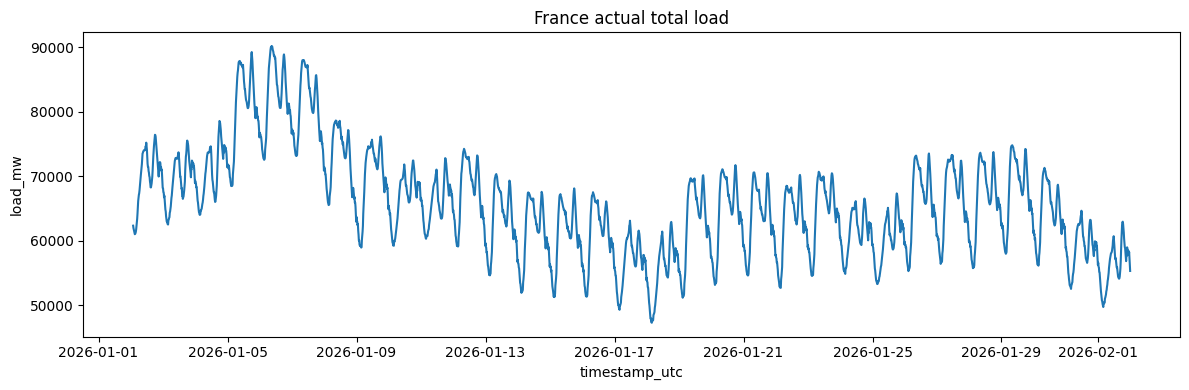

In [46]:
plot_time_series(
    fr_load.sort_values("timestamp_utc"),
    x="timestamp_utc",
    y="load_mw",
    title="France actual total load",
)

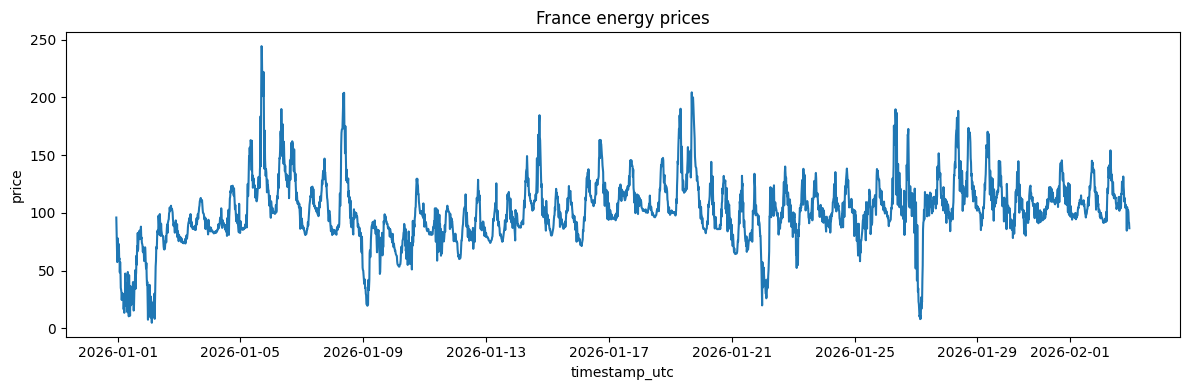

In [47]:
plot_time_series(
    fr_price.sort_values("timestamp_utc"),
    x="timestamp_utc",
    y="price",
    title="France energy prices",
)

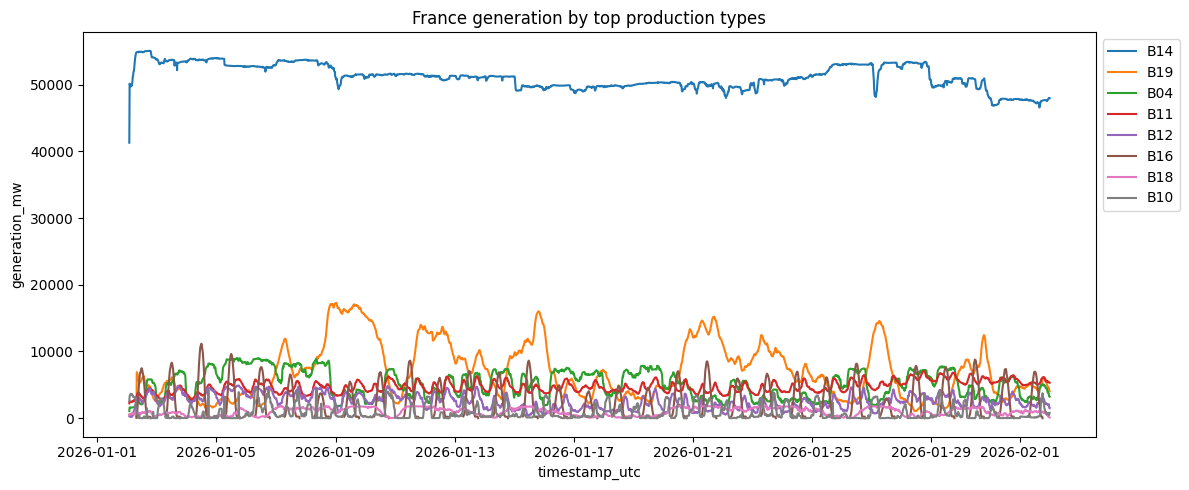

In [48]:
if not fr_gen.empty:
    gen_pivot = (
        fr_gen.groupby(["timestamp_utc", "psr_type"], as_index=False)["generation_mw"]
        .sum()
        .pivot(index="timestamp_utc", columns="psr_type", values="generation_mw")
        .sort_index()
    )

    top_psr = gen_pivot.sum().sort_values(ascending=False).head(8).index.tolist()

    plt.figure(figsize=(12, 5))
    for psr in top_psr:
        plt.plot(gen_pivot.index, gen_pivot[psr], label=psr)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.title("France generation by top production types")
    plt.xlabel("timestamp_utc")
    plt.ylabel("generation_mw")
    plt.tight_layout()
    plt.show()
else:
    print("No France generation data.")

## GB plots

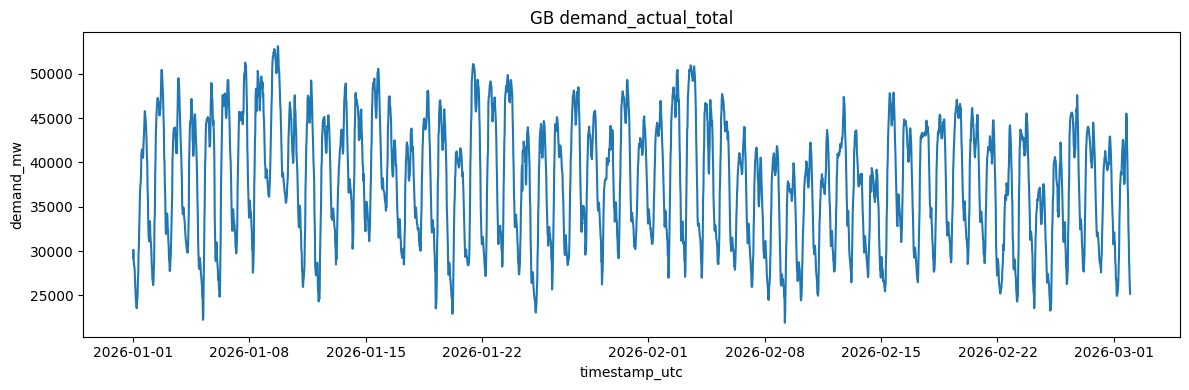

In [49]:
plot_time_series(
    gb_load.sort_values("timestamp_utc"),
    x="timestamp_utc",
    y="demand_mw",
    title="GB demand_actual_total",
)

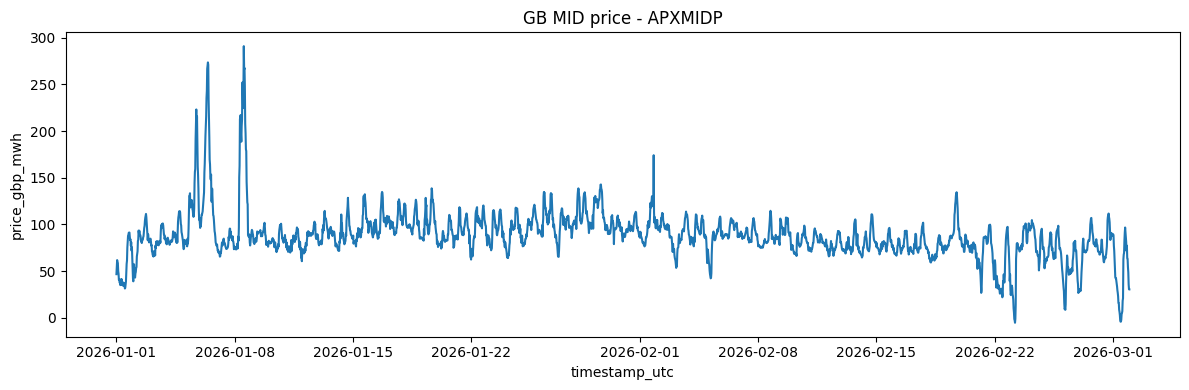

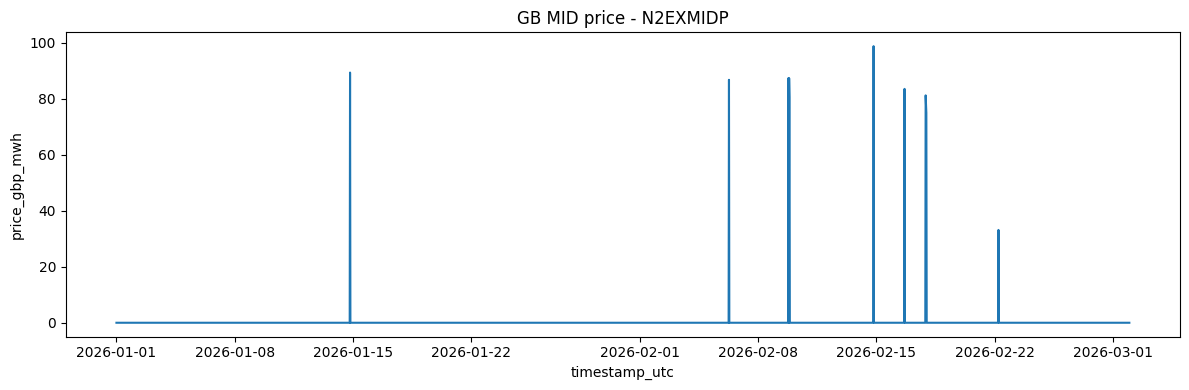

In [50]:
# Keep provider rows separate first
gb_price_sorted = gb_price.sort_values("timestamp_utc")

for provider in sorted(gb_price_sorted["data_provider"].dropna().unique()):
    subset = gb_price_sorted[gb_price_sorted["data_provider"] == provider]
    plt.figure(figsize=(12, 4))
    plt.plot(subset["timestamp_utc"], subset["price_gbp_mwh"])
    plt.title(f"GB MID price - {provider}")
    plt.xlabel("timestamp_utc")
    plt.ylabel("price_gbp_mwh")
    plt.tight_layout()
    plt.show()

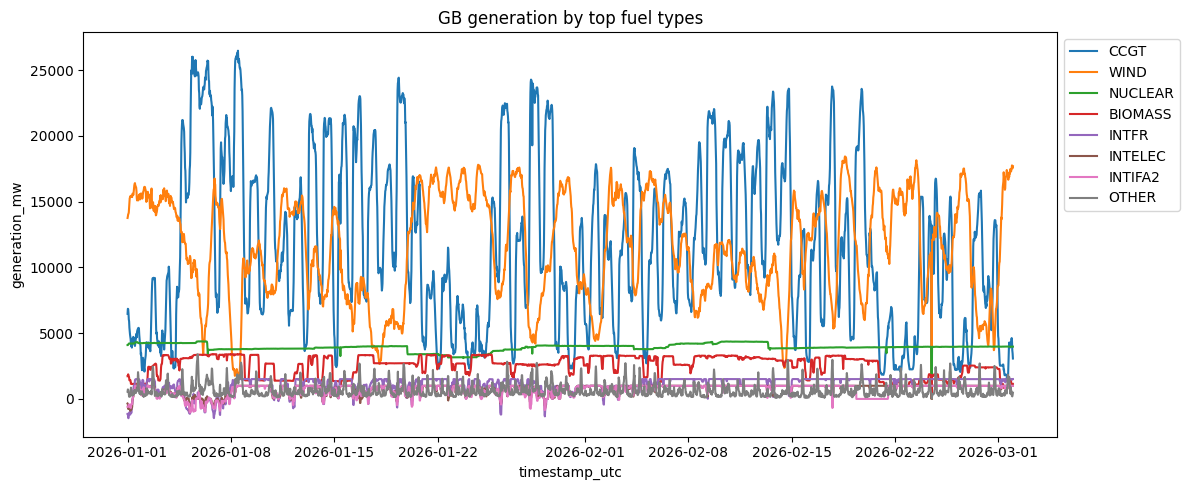

In [51]:
if not gb_gen.empty:
    gb_gen_pivot = (
        gb_gen.groupby(["timestamp_utc", "fuel_type"], as_index=False)["generation_mw"]
        .sum()
        .pivot(index="timestamp_utc", columns="fuel_type", values="generation_mw")
        .sort_index()
    )

    top_fuels = gb_gen_pivot.sum().sort_values(ascending=False).head(8).index.tolist()

    plt.figure(figsize=(12, 5))
    for fuel in top_fuels:
        plt.plot(gb_gen_pivot.index, gb_gen_pivot[fuel], label=fuel)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.title("GB generation by top fuel types")
    plt.xlabel("timestamp_utc")
    plt.ylabel("generation_mw")
    plt.tight_layout()
    plt.show()
else:
    print("No GB generation data.")

## Quick comparison: GB vs FR

,date,fr_load_mean,gb_load_mean
0,2026-01-02,70130.944157,39536.604167
1,2026-01-03,69406.980625,38775.937500
2,2026-01-04,70725.407500,37666.875000
3,2026-01-05,80564.802812,37620.041667
4,2026-01-06,82369.401875,39223.458333


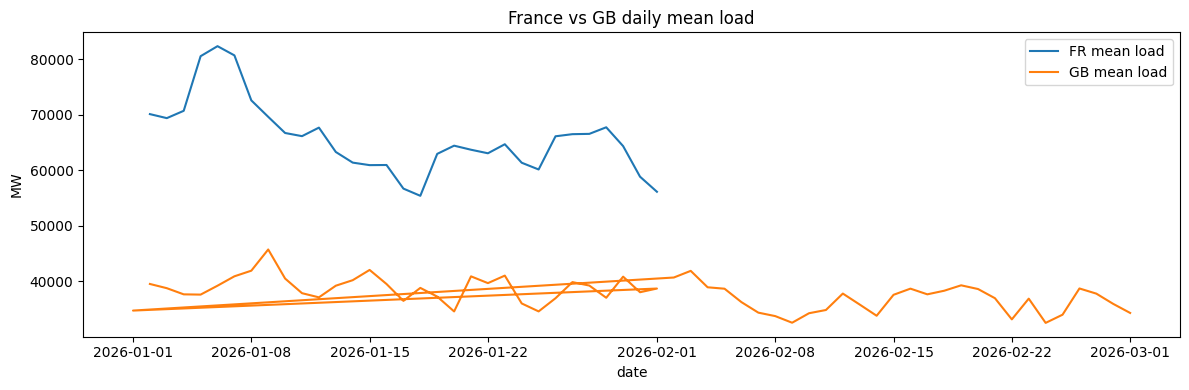

In [52]:
fr_load_daily = (
    fr_load.groupby(fr_load["timestamp_utc"].dt.date)["load_mw"]
    .mean()
    .rename("fr_load_mean")
)

gb_load_daily = (
    gb_load.groupby(gb_load["timestamp_utc"].dt.date)["demand_mw"]
    .mean()
    .rename("gb_load_mean")
)

load_compare = pd.concat([fr_load_daily, gb_load_daily], axis=1).reset_index().rename(columns={"timestamp_utc": "date"})
display(load_compare.head())

plt.figure(figsize=(12, 4))
plt.plot(load_compare["date"], load_compare["fr_load_mean"], label="FR mean load")
plt.plot(load_compare["date"], load_compare["gb_load_mean"], label="GB mean load")
plt.legend()
plt.title("France vs GB daily mean load")
plt.xlabel("date")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

## Daily expected-row validation for ENTSO-E load

In [53]:
def expected_rows_from_resolution(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["date", "resolution", "rows"])

    out = (
        df.assign(
            date=df["timestamp_utc"].dt.date,
            resolution=df["resolution"].astype(str),
        )
        .groupby(["date", "resolution"])
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(["date", "resolution"])
    )
    return out


fr_load_expected = expected_rows_from_resolution(fr_load)
display(fr_load_expected.head(20))

,date,resolution,rows
0,2026-01-02,PT15M,89
1,2026-01-03,PT15M,96
2,2026-01-04,PT15M,96
3,2026-01-05,PT15M,96
4,2026-01-06,PT15M,96
5,2026-01-07,PT15M,96
6,2026-01-08,PT15M,96
7,2026-01-09,PT15M,96
8,2026-01-10,PT15M,96
9,2026-01-11,PT15M,96


## Zone level summary friction

In [54]:
def summarise_entsoe_zone(zone: str) -> pd.DataFrame:
    rows = []

    for dataset in ["actual_total_load", "generation_per_type", "energy_prices"]:
        df = load_entsoe_zone_dataset(zone, dataset)

        rows.append(
            {
                "zone": zone,
                "dataset": dataset,
                "rows": len(df),
                "min_ts": df["timestamp_utc"].min() if "timestamp_utc" in df.columns and not df.empty else pd.NaT,
                "max_ts": df["timestamp_utc"].max() if "timestamp_utc" in df.columns and not df.empty else pd.NaT,
                "columns": ", ".join(df.columns[:8]) + (" ..." if len(df.columns) > 8 else ""),
            }
        )

    return pd.DataFrame(rows)


zone_summaries = pd.concat([summarise_entsoe_zone(z) for z in sorted(entsoe_inventory["zone"].unique())], ignore_index=True)
display(zone_summaries)

,zone,dataset,rows,min_ts,max_ts,columns
0,be,actual_total_load,3072,2026-01-01 00:00:00+00:00,2026-02-01 23:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
1,be,generation_per_type,7978,2026-01-01 00:00:00+00:00,2026-02-01 23:00:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
2,be,energy_prices,6120,2025-12-31 23:00:00+00:00,2026-02-02 22:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
3,de_lu,actual_total_load,3072,2026-01-01 00:00:00+00:00,2026-02-01 23:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
4,de_lu,generation_per_type,42095,2026-01-01 00:00:00+00:00,2026-02-01 23:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
5,de_lu,energy_prices,6139,2025-12-31 23:00:00+00:00,2026-02-02 22:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
6,dk1,actual_total_load,768,2026-01-01 00:00:00+00:00,2026-02-01 23:00:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
7,dk1,generation_per_type,27770,2026-01-01 00:00:00+00:00,2026-02-01 23:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
8,dk1,energy_prices,6100,2025-12-31 23:00:00+00:00,2026-02-02 22:45:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."
9,dk2,actual_total_load,768,2026-01-01 00:00:00+00:00,2026-02-01 23:00:00+00:00,"timestamp_utc, period_start_utc, period_end_ut..."


## Find suspicious days

In [55]:
def suspicious_days(zone: str, dataset: str, min_rows_threshold: int = 1) -> pd.DataFrame:
    counts = daily_row_counts_entsoe(zone, dataset)
    if counts.empty:
        return counts

    return counts[counts["rows"] <= min_rows_threshold].sort_values("date").reset_index(drop=True)


display(suspicious_days("fr", "actual_total_load", min_rows_threshold=10))
display(suspicious_days("ie_sem", "actual_total_load", min_rows_threshold=10))

,date,rows


,date,rows


## Optional: Explore problematic data frame

In [56]:
example_path = None

subset = entsoe_inventory[
    (entsoe_inventory["zone"] == "fr") &
    (entsoe_inventory["dataset"] == "actual_total_load")
]

if not subset.empty:
    example_path = Path(subset.iloc[0]["path"])
    print(example_path)

if example_path:
    df_example = pd.read_parquet(example_path)
    display(df_example.head(20))
    print(df_example.columns.tolist())
    print("rows:", len(df_example))

/Users/benjaminperryman/Personal Coding/interconnector-flow-model/data/silver/entsoe/fr/actual_total_load/year=2026/month=01/actual_total_load_2026-01-01.parquet


,timestamp_utc,period_start_utc,period_end_utc,resolution,position,zone_code,area_code,load_mw,unit,source


['timestamp_utc', 'period_start_utc', 'period_end_utc', 'resolution', 'position', 'zone_code', 'area_code', 'load_mw', 'unit', 'source']
rows: 0
